In [283]:
from __future__ import annotations

import json
import logging
import logging.config
import os
import time
import warnings
from datetime import datetime
from pathlib import Path
from typing import Any

import joblib
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from pydantic import BaseModel, ConfigDict
from sqlalchemy import create_engine, text

# Imbalanced-Learn and Sklearn logic
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, average_precision_score, balanced_accuracy_score, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Filter warnings
warnings.filterwarnings("ignore", category=UserWarning)

# --- Configuration & Logging ---
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s - %(message)s",
)
logger = logging.getLogger(__name__)

# --- Database Setup (from environment) ---
# DEBUG OVERRIDE: Using 'localhost' instead of the docker hostname 'postgres' since we are running outside the container.
DB_HOST = os.environ.get("DB_HOST", "localhost")
DB_PORT = os.environ.get("DB_PORT", "5432")
DB_USER = os.environ.get("DB_USER", "postgres")
DB_PASSWORD = os.environ.get("DB_PASSWORD", "postgres")
DB_NAME = os.environ.get("DB_NAME", "maghrebia_dwh")
DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
db_engine = create_engine(DATABASE_URL)

# --- Constants & Feature Definitions ---
PROMOTION_MIN_DELTA = 0.01

TARGET_COLUMN = "is_impaye"
EVENT_MONTH_COLUMN = "event_month"

HISTORICAL_NUMERIC_FEATURES = [
    "client_impaye_count",
    "client_total_prime_impaye",
    "client_total_prime_paid",
    "client_impaye_ratio",
    "police_impaye_count",
    "police_impaye_ratio",
    "police_total_prime_impaye",
    "police_total_prime_paid",
    "agent_impaye_count",
    "agent_impaye_ratio",
]

ENGINEERED_NUMERIC_FEATURES = [
    "client_months_since_last_impaye",
    "police_months_since_last_impaye",
    "client_hist_impaye_rate",
    "police_hist_impaye_rate",
    "client_prime_trend",
    "relative_prime_to_client_avg",
    "relative_prime_to_agent_avg",
]

BASE_NUMERIC_FEATURES = [
    "prime_totale",
    "prime_nette",
    "fractionnement",
    "vehicule_puissance",
    "vehicule_valeur_neuf",
    "vehicule_valeur_venale",
    "client_age",
    "client_anciennete_mois",
]

NUMERIC_FEATURES = BASE_NUMERIC_FEATURES + HISTORICAL_NUMERIC_FEATURES + ENGINEERED_NUMERIC_FEATURES

CATEGORICAL_FEATURES = [
    "branch_id",
    "type_avenant",
    "type_quittance",
    "nature_police",
    "code_cancellation",
    "client_type",
    "client_secteur_activite",
    "agent_type",
    "vehicule_usage",
    "vehicule_energie",
    "vehicule_marque",
]

FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

SPLIT_STRATEGIES = {"temporal", "random"}

try:
    _base_dir = Path(__file__).resolve().parent
except NameError:
    _base_dir = Path.cwd()

_models_dir = _base_dir / "models"
_default_champion_model_path = _models_dir / "impaye_risk_model.joblib"
_default_latest_model_path = _models_dir / "impaye_risk_model_latest.joblib"

_models_dir.mkdir(parents=True, exist_ok=True)

In [284]:
def _safe_float(value: str | None, default: float) -> float:
    if value is None:
        return float(default)

    raw = value.strip()
    if not raw:
        return float(default)

    try:
        return float(raw)
    except ValueError:
        return float(default)

In [285]:
def _normalize_policy_env(value: str | None) -> str:
    raw = (value or "").strip().lower()
    return PROMOTION_POLICY_ENV_ALIASES.get(raw, "development")

In [286]:
def get_promotion_policy() -> dict[str, Any]:
    raw_policy_env = (
        os.getenv("PROMOTION_POLICY_ENV")
        or os.getenv("APP_ENV")
        or os.getenv("ENVIRONMENT")
    )
    policy_env = _normalize_policy_env(raw_policy_env)
    min_delta = float(PROMOTION_MIN_DELTA_DEFAULTS[policy_env])

    env_specific_key = f"PROMOTION_MIN_DELTA_{policy_env.upper()}"
    env_specific_value = os.getenv(env_specific_key)
    global_value = os.getenv("PROMOTION_MIN_DELTA")

    if env_specific_value is not None and env_specific_value.strip() != "":
        min_delta = _safe_float(env_specific_value, min_delta)
    elif global_value is not None and global_value.strip() != "":
        min_delta = _safe_float(global_value, min_delta)

    return {
        "policy_env": policy_env,
        "promotion_metrics": list(PROMOTION_METRICS),
        "promotion_min_delta": float(min_delta),
        "env_specific_key": env_specific_key,
        "global_key": "PROMOTION_MIN_DELTA",
    }

In [287]:
def _safe_int(value: str | None, default: int) -> int:
    if value is None:
        return int(default)

    raw = value.strip()
    if not raw:
        return int(default)

    try:
        return int(raw)
    except ValueError:
        return int(default)

In [288]:
def _safe_bool(value: str | None, default: bool) -> bool:
    if value is None:
        return bool(default)

    raw = value.strip().lower()
    if not raw:
        return bool(default)

    if raw in {"1", "true", "yes", "y", "on"}:
        return True
    if raw in {"0", "false", "no", "n", "off"}:
        return False
    return bool(default)

In [289]:
def _status_higher_better(value: float | None, pass_min: float, warn_min: float) -> str:
    if value is None:
        return "fail"
    if value >= pass_min:
        return "pass"
    if value >= warn_min:
        return "warn"
    return "fail"

In [290]:
def _status_lower_better(value: float | None, pass_max: float, warn_max: float) -> str:
    if value is None:
        return "fail"
    if value <= pass_max:
        return "pass"
    if value <= warn_max:
        return "warn"
    return "fail"

In [291]:
def _load_recent_impaye_observed_rate(months: int, engine: Engine = db_engine) -> dict[str, Any]:
    months_back = max(int(months) - 1, 0)

    sql = text(
        """
        WITH emission_window AS (
            SELECT e.num_quittance
            FROM dwh_fact_emission e
            WHERE e.etat_quit IN ('E', 'P', 'A')
              AND make_date(e.annee_echeance, e.mois_echeance, 1)
                  >= date_trunc('month', current_date) - (interval '1 month' * :months_back)
        ),
        impaye_ref AS (
            SELECT DISTINCT num_quittance
            FROM dwh_fact_impaye
        )
        SELECT
            COUNT(*)::int AS emissions_count,
            COUNT(i.num_quittance)::int AS impaye_count,
            COALESCE(COUNT(i.num_quittance)::float / NULLIF(COUNT(*), 0), 0.0) AS observed_impaye_rate
        FROM emission_window w
        LEFT JOIN impaye_ref i ON i.num_quittance = w.num_quittance
        """
    )

    row = pd.read_sql(sql, engine, params={"months_back": months_back}).iloc[0]
    return {
        "emissions_count": int(row["emissions_count"]),
        "impaye_count": int(row["impaye_count"]),
        "observed_impaye_rate": float(row["observed_impaye_rate"]),
        "months": int(months),
    }

In [292]:
def get_impaye_operations_readiness(months: int = 6) -> dict[str, Any]:
    """
    TDSP Phase 4 (Déploiement ML): readiness opérationnelle du modèle impayé.

    Le score combine performance modèle, fraîcheur, calibration business et volume
    opérationnel récent pour piloter les décisions CEO/recouvrement.
    """

    window_months = max(1, min(int(months), 24))
    promotion_policy = get_promotion_policy()
    champion = load_model_metadata()
    metrics = champion.get("metrics", {})

    max_model_age_days = _safe_int(os.getenv("OPS_MAX_MODEL_AGE_DAYS"), 45)
    min_recall = _safe_float(os.getenv("OPS_MIN_RECALL"), 0.25)
    min_avg_precision_lift = _safe_float(os.getenv("OPS_MIN_AVG_PRECISION_LIFT"), 1.05)
    max_predicted_positive_rate = _safe_float(os.getenv("OPS_MAX_PREDICTED_POSITIVE_RATE"), 0.35)
    max_rate_gap = _safe_float(os.getenv("OPS_MAX_RATE_GAP"), 0.15)
    min_recent_emissions = _safe_int(os.getenv("OPS_MIN_RECENT_EMISSIONS"), 1000)

    trained_at_raw = champion.get("trained_at")
    trained_at = pd.to_datetime(trained_at_raw, errors="coerce", utc=True)
    if pd.isna(trained_at):
        model_age_days: float | None = None
    else:
        delta = pd.Timestamp.now(tz="UTC") - trained_at
        model_age_days = float(delta.total_seconds() / 86400.0)

    positive_rate = float(champion.get("positive_rate", 0.0) or 0.0)
    avg_precision = float(metrics.get("avg_precision", 0.0) or 0.0)
    recall = float(metrics.get("recall", 0.0) or 0.0)
    predicted_positive_rate = float(metrics.get("predicted_positive_rate", 0.0) or 0.0)
    avg_precision_lift = float(avg_precision / positive_rate) if positive_rate > 0 else 0.0

    recent_signal_error: str | None = None
    recent_signal: dict[str, Any] = {
        "emissions_count": 0,
        "impaye_count": 0,
        "observed_impaye_rate": 0.0,
        "months": window_months,
    }
    try:
        recent_signal = _load_recent_impaye_observed_rate(window_months)
    except Exception as exc:
        recent_signal_error = str(exc)

    observed_impaye_rate = float(recent_signal.get("observed_impaye_rate", 0.0) or 0.0)
    rate_gap = abs(predicted_positive_rate - observed_impaye_rate)

    checks: list[dict[str, Any]] = []

    checks.append(
        {
            "name": "model_freshness",
            "status": _status_lower_better(
                model_age_days,
                pass_max=float(max_model_age_days),
                warn_max=float(max_model_age_days) * 1.5,
            ),
            "value": model_age_days,
            "threshold": {
                "pass_max_days": float(max_model_age_days),
                "warn_max_days": float(max_model_age_days) * 1.5,
            },
            "tdsp_link": "Phase 4 - Monitoring de modele",
        }
    )

    checks.append(
        {
            "name": "recall_on_impaye",
            "status": _status_higher_better(
                recall,
                pass_min=min_recall,
                warn_min=min_recall * 0.8,
            ),
            "value": recall,
            "threshold": {
                "pass_min": min_recall,
                "warn_min": min_recall * 0.8,
            },
            "tdsp_link": "Phase 4 - Performance operationnelle",
        }
    )

    checks.append(
        {
            "name": "avg_precision_lift",
            "status": _status_higher_better(
                avg_precision_lift,
                pass_min=min_avg_precision_lift,
                warn_min=min_avg_precision_lift * 0.8,
            ),
            "value": avg_precision_lift,
            "threshold": {
                "pass_min": min_avg_precision_lift,
                "warn_min": min_avg_precision_lift * 0.8,
            },
            "tdsp_link": "Phase 4 - Valeur metier vs baseline",
        }
    )

    checks.append(
        {
            "name": "predicted_positive_rate",
            "status": _status_lower_better(
                predicted_positive_rate,
                pass_max=max_predicted_positive_rate,
                warn_max=max_predicted_positive_rate * 1.2,
            ),
            "value": predicted_positive_rate,
            "threshold": {
                "pass_max": max_predicted_positive_rate,
                "warn_max": max_predicted_positive_rate * 1.2,
            },
            "tdsp_link": "Phase 4 - Charge operationnelle recouvrement",
        }
    )

    emissions_count = int(recent_signal.get("emissions_count", 0) or 0)
    checks.append(
        {
            "name": "recent_data_coverage",
            "status": _status_higher_better(
                float(emissions_count),
                pass_min=float(min_recent_emissions),
                warn_min=float(min_recent_emissions) * 0.5,
            ),
            "value": emissions_count,
            "threshold": {
                "pass_min": min_recent_emissions,
                "warn_min": int(min_recent_emissions * 0.5),
            },
            "tdsp_link": "Phase 4 - Fiabilite des donnees en production",
        }
    )

    calibration_status = _status_lower_better(
        rate_gap,
        pass_max=max_rate_gap,
        warn_max=max_rate_gap * 1.5,
    )
    if recent_signal_error:
        calibration_status = "fail"
    checks.append(
        {
            "name": "predicted_vs_observed_rate_gap",
            "status": calibration_status,
            "value": rate_gap,
            "threshold": {
                "pass_max": max_rate_gap,
                "warn_max": max_rate_gap * 1.5,
            },
            "observed_impaye_rate": observed_impaye_rate,
            "tdsp_link": "Phase 4 - Surveillance de derive metier",
            "data_error": recent_signal_error,
        }
    )

    pass_count = sum(1 for check in checks if check["status"] == "pass")
    warn_count = sum(1 for check in checks if check["status"] == "warn")
    fail_count = sum(1 for check in checks if check["status"] == "fail")
    total_checks = len(checks)
    readiness_score = round(((pass_count + 0.5 * warn_count) / total_checks) * 100.0, 2)

    if fail_count > 0:
        readiness_status = "red"
    elif warn_count > 0:
        readiness_status = "amber"
    else:
        readiness_status = "green"

    recommendations: list[str] = []
    status_map = {check["name"]: check["status"] for check in checks}
    if status_map.get("model_freshness") != "pass":
        recommendations.append(
            "Declencher un retrain prioritaire via Airflow pour maintenir la fraicheur du champion."
        )
    if status_map.get("recall_on_impaye") == "fail":
        recommendations.append(
            "Recalibrer le seuil de decision pour augmenter la couverture des impayes critiques."
        )
    if status_map.get("avg_precision_lift") != "pass":
        recommendations.append(
            "Enrichir les features historiques client/agent avant prochaine promotion champion."
        )
    if status_map.get("predicted_vs_observed_rate_gap") != "pass":
        recommendations.append(
            "Lancer une analyse drift par branche et ajuster la politique de promotion si necessaire."
        )
    if status_map.get("recent_data_coverage") == "fail":
        recommendations.append(
            "Verifier le flux TDSP Phase 2 (extract-clean-load) car le volume recent est insuffisant."
        )

    return {
        "tdsp": {
            "phase": "Phase 4 - Deploiement ML et Monitoring",
            "business_objective": "Reduire les impayes en priorisant les actions de recouvrement sur les dossiers a risque.",
            "decision_context": "Comite CEO Risk & Collection",
        },
        "window_months": window_months,
        "readiness": {
            "status": readiness_status,
            "score": readiness_score,
            "pass_count": pass_count,
            "warn_count": warn_count,
            "fail_count": fail_count,
            "total_checks": total_checks,
        },
        "model": {
            "run_id": champion.get("run_id"),
            "trained_at": trained_at_raw,
            "age_days": model_age_days,
            "positive_rate_train": positive_rate,
            "metrics": {
                "avg_precision": avg_precision,
                "recall": recall,
                "predicted_positive_rate": predicted_positive_rate,
                "avg_precision_lift": avg_precision_lift,
            },
            "promotion_policy": promotion_policy,
        },
        "recent_business_signal": recent_signal,
        "checks": checks,
        "recommendations": recommendations,
    }

In [293]:
def resolve_champion_paths(
    model_path: str | Path | None = None,
    metadata_path: str | Path | None = None,
) -> tuple[Path, Path]:
    resolved_model_path = Path(model_path) if model_path else CHAMPION_MODEL_PATH
    resolved_metadata_path = Path(metadata_path) if metadata_path else CHAMPION_METADATA_PATH
    return resolved_model_path, resolved_metadata_path

In [294]:
def resolve_latest_paths(
    model_path: str | Path | None = None,
    metadata_path: str | Path | None = None,
) -> tuple[Path, Path]:
    resolved_model_path = Path(model_path) if model_path else LATEST_MODEL_PATH
    resolved_metadata_path = Path(metadata_path) if metadata_path else LATEST_METADATA_PATH
    return resolved_model_path, resolved_metadata_path

In [295]:
def resolve_model_paths(
    model_path: str | Path | None = None,
    metadata_path: str | Path | None = None,
) -> tuple[Path, Path]:
    return resolve_champion_paths(model_path=model_path, metadata_path=metadata_path)

In [296]:
def _read_json_or_none(path: Path) -> dict[str, Any] | None:
    if not path.exists():
        return None
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return None

In [297]:
def _rank_metrics(metrics: dict[str, Any] | None) -> tuple[float, float, float, float]:
    payload = metrics or {}
    return tuple(float(payload.get(metric, 0.0) or 0.0) for metric in PROMOTION_METRICS)

In [298]:
def _evaluate_promotion(
    challenger_metrics: dict[str, Any],
    champion_metrics: dict[str, Any] | None,
    champion_exists: bool,
    promote_to_champion: bool,
    promotion_policy: dict[str, Any] | None = None,
) -> tuple[bool, str, dict[str, Any]]:
    policy = promotion_policy or get_promotion_policy()
    promotion_min_delta = float(policy.get("promotion_min_delta", 0.0) or 0.0)
    policy_env = str(policy.get("policy_env", "development"))

    challenger_rank = _rank_metrics(challenger_metrics)
    champion_rank = _rank_metrics(champion_metrics)
    comparison = {
        "promotion_metrics": list(PROMOTION_METRICS),
        "promotion_min_delta": promotion_min_delta,
        "promotion_policy_env": policy_env,
        "challenger_rank": list(challenger_rank),
        "champion_rank": list(champion_rank),
        "rank_improvement": [
            float(challenger_rank[i] - champion_rank[i]) for i in range(len(PROMOTION_METRICS))
        ],
    }

    if not promote_to_champion:
        return False, "promotion_disabled", comparison

    if not champion_exists:
        return True, "no_existing_champion", comparison

    primary_delta = challenger_rank[0] - champion_rank[0]
    comparison["primary_metric_delta"] = float(primary_delta)
    if primary_delta < promotion_min_delta:
        return False, "below_min_delta", comparison

    if challenger_rank > champion_rank:
        return True, "better_metrics", comparison

    return False, "not_better_than_champion", comparison

In [299]:
def _append_governance_event(event: dict[str, Any]) -> None:
    GOVERNANCE_HISTORY_PATH.parent.mkdir(parents=True, exist_ok=True)
    with GOVERNANCE_HISTORY_PATH.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(event, ensure_ascii=False) + "\n")

In [300]:
def _read_governance_events(limit: int = 20) -> list[dict[str, Any]]:
    if not GOVERNANCE_HISTORY_PATH.exists():
        return []

    events: list[dict[str, Any]] = []
    with GOVERNANCE_HISTORY_PATH.open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            try:
                events.append(json.loads(line))
            except json.JSONDecodeError:
                continue

    if limit <= 0:
        return list(reversed(events))

    return list(reversed(events[-limit:]))

In [301]:
def _training_query() -> str:
    return """
    WITH impaye_quittances AS (
        SELECT DISTINCT num_quittance
        FROM dwh_fact_impaye
    )
    SELECT
        e.num_quittance,
        COALESCE(e.id_agent, 0) AS id_agent,
        COALESCE(e.id_police, 0) AS id_police,
        COALESCE(p.id_client, 0) AS id_client,
        COALESCE(e.branche, 'AUTO') AS branche,
        COALESCE(e.periodicite, 'A') AS periodicite,
        COALESCE(p.situation, 'V') AS police_situation,
        COALESCE(c.type_personne, 'U') AS type_personne,
        COALESCE(c.sexe, 'U') AS sexe,
        COALESCE(c.ville, 'UNKNOWN') AS ville_client,
        COALESCE(a.groupe_agent, 'UNKNOWN') AS groupe_agent,
        COALESCE(a.type_agent, 'UNKNOWN') AS type_agent,
        COALESCE(p.type_police, 'UNKNOWN') AS type_police,
        COALESCE(p.duree, 'UNKNOWN') AS duree_police,
        c.date_naissance,
        COALESCE(e.date_effet, p.date_effet) AS date_effet_police,
        COALESCE(e.annee_echeance, 2024) AS annee_echeance,
        COALESCE(e.mois_echeance, 1) AS mois_echeance,
        COALESCE(e.mt_pnet, 0.0) AS mt_pnet,
        COALESCE(e.mt_rc, 0.0) AS mt_rc,
        COALESCE(e.mt_fga, 0.0) AS mt_fga,
        COALESCE(e.mt_timbre, 0.0) AS mt_timbre,
        COALESCE(e.mt_taxe, 0.0) AS mt_taxe,
        COALESCE(e.mt_ptt, 0.0) AS mt_ptt,
        COALESCE(e.mt_commission, 0.0) AS mt_commission,
        COALESCE(e.bonus_malus, 1.0) AS bonus_malus,
        CASE WHEN iq.num_quittance IS NULL THEN 0 ELSE 1 END AS target_impaye
    FROM dwh_fact_emission e
    LEFT JOIN impaye_quittances iq ON iq.num_quittance = e.num_quittance
    LEFT JOIN dim_police p ON p.id_police = e.id_police
        LEFT JOIN dim_client c ON c.id_client = p.id_client
        LEFT JOIN dim_agent a ON a.id_agent = e.id_agent
    WHERE e.etat_quit IN ('E', 'P', 'A')
      AND (:year_from IS NULL OR e.annee_echeance >= :year_from)
      AND (:year_to IS NULL OR e.annee_echeance <= :year_to)
    """

In [302]:
def _add_historical_features(df: pd.DataFrame) -> pd.DataFrame:
    enriched = df.copy()

    for feature in HISTORICAL_NUMERIC_FEATURES:
        enriched[feature] = 999.0 if feature.endswith("months_since_last_impaye") else 0.0

    if "policy_pnet_change_ratio" not in enriched.columns:
        enriched["policy_pnet_change_ratio"] = 0.0

    if TARGET_COLUMN not in enriched.columns:
        return enriched

    ordered = enriched.sort_values([EVENT_MONTH_COLUMN, "num_quittance"], kind="mergesort").copy()
    month_idx = (
        pd.to_datetime(ordered[EVENT_MONTH_COLUMN], errors="coerce").dt.year * 12
        + pd.to_datetime(ordered[EVENT_MONTH_COLUMN], errors="coerce").dt.month
    ).astype(float)

    def _compute_group_history(key_col: str, prefix: str) -> None:
        if key_col not in ordered.columns:
            return

        key = ordered[key_col].fillna(-1)
        counts = ordered.groupby(key, sort=False).cumcount()
        previous_impaye = ordered.groupby(key, sort=False)[TARGET_COLUMN].cumsum() - ordered[TARGET_COLUMN]
        ordered[f"{prefix}_hist_count"] = counts.astype(float)
        ordered[f"{prefix}_hist_impaye_rate"] = np.where(
            counts > 0,
            previous_impaye / counts,
            0.0,
        ).astype(float)

    def _compute_group_recency(key_col: str, prefix: str) -> None:
        if key_col not in ordered.columns:
            return

        key = ordered[key_col].fillna("UNKNOWN")
        impaye_month_idx = month_idx.where(ordered[TARGET_COLUMN] == 1, np.nan)
        prev_last_impaye_idx = impaye_month_idx.groupby(key, sort=False).transform(
            lambda s: s.ffill().shift(1)
        )
        months_since = (month_idx - prev_last_impaye_idx).astype(float)
        ordered[f"{prefix}_months_since_last_impaye"] = (
            months_since.where(prev_last_impaye_idx.notna(), 999.0)
            .clip(lower=0, upper=999)
            .astype(float)
        )

    _compute_group_history("id_agent", "agent")
    _compute_group_history("id_client", "client")
    _compute_group_history("id_police", "police")
    _compute_group_history("branche", "branche")
    _compute_group_history("ville_client", "ville")
    _compute_group_history("groupe_agent", "groupe_agent")

    _compute_group_recency("id_agent", "agent")
    _compute_group_recency("id_client", "client")
    _compute_group_recency("id_police", "police")
    _compute_group_recency("branche", "branche")
    _compute_group_recency("ville_client", "ville")
    _compute_group_recency("groupe_agent", "groupe_agent")

    if "id_police" in ordered.columns and "mt_pnet" in ordered.columns:
        police_key = ordered["id_police"].fillna(-1)
        prev_pnet = ordered.groupby(police_key, sort=False)["mt_pnet"].shift(1)
        base_prev_pnet = prev_pnet.abs().clip(lower=1.0)
        ordered["policy_pnet_change_ratio"] = (
            ((ordered["mt_pnet"] - prev_pnet) / base_prev_pnet)
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0.0)
            .clip(lower=-3, upper=3)
            .astype(float)
        )

    enriched.loc[ordered.index, HISTORICAL_NUMERIC_FEATURES] = ordered[HISTORICAL_NUMERIC_FEATURES]
    if "policy_pnet_change_ratio" in ordered.columns:
        enriched.loc[ordered.index, "policy_pnet_change_ratio"] = ordered["policy_pnet_change_ratio"]
    return enriched

In [303]:
def _apply_feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    prepared = df.copy()

    if TARGET_COLUMN in prepared.columns:
        prepared[TARGET_COLUMN] = pd.to_numeric(prepared[TARGET_COLUMN], errors="coerce").fillna(0).astype(int)

    if "num_quittance" not in prepared.columns:
        prepared["num_quittance"] = prepared.index.astype(str)

    for column in BASE_NUMERIC_FEATURES:
        if column not in prepared.columns:
            prepared[column] = np.nan
        prepared[column] = pd.to_numeric(prepared[column], errors="coerce")

    prepared["mois_echeance"] = prepared["mois_echeance"].fillna(1).clip(1, 12)
    prepared["annee_echeance"] = prepared["annee_echeance"].fillna(2024).clip(2018, 2100)

    prepared[EVENT_MONTH_COLUMN] = pd.to_datetime(
        {
            "year": prepared["annee_echeance"].round().astype(int),
            "month": prepared["mois_echeance"].round().astype(int),
            "day": 1,
        },
        errors="coerce",
    )
    prepared[EVENT_MONTH_COLUMN] = prepared[EVENT_MONTH_COLUMN].fillna(pd.Timestamp("2024-01-01"))

    birth_raw = (
        prepared["date_naissance"]
        if "date_naissance" in prepared.columns
        else pd.Series(pd.NaT, index=prepared.index)
    )
    birth_date = pd.to_datetime(birth_raw, errors="coerce")

    if "date_effet_police" in prepared.columns:
        policy_raw = prepared["date_effet_police"]
    elif "date_effet" in prepared.columns:
        policy_raw = prepared["date_effet"]
    else:
        policy_raw = pd.Series(pd.NaT, index=prepared.index)
    policy_start = pd.to_datetime(policy_raw, errors="coerce")
    event_month = prepared[EVENT_MONTH_COLUMN]

    prepared["client_age_years"] = ((event_month - birth_date).dt.days / 365.25).clip(18, 100)
    prepared["policy_tenure_months"] = (
        (event_month.dt.year - policy_start.dt.year) * 12
        + (event_month.dt.month - policy_start.dt.month)
    ).clip(lower=0, upper=480)

    type_personne_source = (
        prepared.get("type_personne", pd.Series("UNKNOWN", index=prepared.index))
        .astype(str)
        .str.upper()
        .str.strip()
    )
    prepared["is_personne_morale"] = np.where(type_personne_source == "M", 1.0, 0.0)

    pnet_safe = prepared["mt_pnet"].abs().clip(lower=1.0)
    prepared["commission_rate"] = (prepared["mt_commission"] / pnet_safe).clip(lower=0, upper=3)
    prepared["rc_share"] = (prepared["mt_rc"] / pnet_safe).clip(lower=0, upper=3)
    prepared["fga_rate"] = (prepared["mt_fga"] / pnet_safe).clip(lower=0, upper=3)
    prepared["tax_rate"] = ((prepared["mt_taxe"] + prepared["mt_timbre"]) / pnet_safe).clip(
        lower=0,
        upper=2,
    )
    prepared["tax_and_fee_share"] = (
        (prepared["mt_taxe"] + prepared["mt_timbre"] + prepared["mt_fga"]) / pnet_safe
    ).clip(lower=0, upper=3)
    expected_ptt = prepared["mt_pnet"] + prepared["mt_fga"] + prepared["mt_timbre"] + prepared["mt_taxe"]
    prepared["ptt_gap"] = ((prepared["mt_ptt"] - expected_ptt) / pnet_safe).clip(lower=-3, upper=3)

    month_index = (prepared["mois_echeance"] - 1).fillna(0)
    month_angle = 2 * np.pi * month_index / 12.0
    prepared["season_sin"] = np.sin(month_angle)
    prepared["season_cos"] = np.cos(month_angle)

    prepared["premium_to_age_ratio"] = (prepared["mt_pnet"] / prepared["client_age_years"].clip(lower=18)).clip(upper=1000)
    prepared["is_new_client"] = np.where(prepared["policy_tenure_months"] <= 12, 1.0, 0.0)
    prepared["has_malus"] = np.where(prepared["bonus_malus"] > 100, 1.0, 0.0)
    prepared["has_bonus"] = np.where(prepared["bonus_malus"] < 100, 1.0, 0.0)
    prepared["rc_to_pnet_ratio"] = (prepared["mt_rc"] / pnet_safe).clip(lower=0, upper=3)

    prepared = _add_historical_features(prepared)

    for column in CATEGORICAL_FEATURES:
        if column not in prepared.columns:
            prepared[column] = "UNKNOWN"
        prepared[column] = prepared[column].astype(str).str.strip().str.upper()

    for column in NUMERIC_FEATURES:
        prepared[column] = pd.to_numeric(prepared[column], errors="coerce")

    return prepared

In [304]:
def load_training_dataset(
    engine: Engine = db_engine,
    year_from: int | None = None,
    year_to: int | None = None,
) -> pd.DataFrame:
    params = {
        "year_from": year_from,
        "year_to": year_to,
    }
    df = pd.read_sql(text(_training_query()), engine, params=params)

    if df.empty:
        return df

    df = _apply_feature_engineering(df)
    df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors="coerce").fillna(0).astype(int)
    return df

In [305]:
def _random_split(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float,
    random_state: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, dict[str, Any]]:
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=random_state,
            stratify=y,
        )
    except ValueError:
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=random_state,
            stratify=None,
        )

    return X_train, X_test, y_train, y_test, {
        "split_strategy_used": "random",
        "train_rows": int(len(X_train)),
        "test_rows": int(len(X_test)),
    }

In [306]:
def _temporal_split(
    dataset: pd.DataFrame,
    test_size: float,
    random_state: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, dict[str, Any]]:
    X = dataset[FEATURE_COLUMNS].copy()
    y = dataset[TARGET_COLUMN].copy()

    if EVENT_MONTH_COLUMN not in dataset.columns:
        return _random_split(X, y, test_size=test_size, random_state=random_state)

    month_period = pd.to_datetime(dataset[EVENT_MONTH_COLUMN], errors="coerce").dt.to_period("M")
    valid_months = month_period.dropna().sort_values().unique()
    if len(valid_months) < 3:
        return _random_split(X, y, test_size=test_size, random_state=random_state)

    n_test_months = max(1, int(np.ceil(len(valid_months) * test_size)))
    test_months = set(valid_months[-n_test_months:])
    is_test = month_period.isin(test_months)

    if is_test.sum() == 0 or (~is_test).sum() == 0:
        return _random_split(X, y, test_size=test_size, random_state=random_state)

    X_train = X.loc[~is_test]
    X_test = X.loc[is_test]
    y_train = y.loc[~is_test]
    y_test = y.loc[is_test]

    if y_train.nunique() < 2:
        return _random_split(X, y, test_size=test_size, random_state=random_state)

    return X_train, X_test, y_train, y_test, {
        "split_strategy_used": "temporal",
        "train_rows": int(len(X_train)),
        "test_rows": int(len(X_test)),
        "temporal_test_month_start": str(min(test_months)),
        "temporal_test_month_end": str(max(test_months)),
        "temporal_test_months": len(test_months),
    }

In [307]:
def _build_preprocessor(
    numeric_features: list[str] | None = None,
    categorical_features: list[str] | None = None,
) -> ColumnTransformer:
    numeric_cols = numeric_features if numeric_features is not None else NUMERIC_FEATURES
    categorical_cols = (
        categorical_features if categorical_features is not None else CATEGORICAL_FEATURES
    )

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols),
        ]
    )

In [308]:
def _get_threshold_policy() -> dict[str, float]:
    min_precision = _safe_float(os.getenv("TRAIN_THRESHOLD_MIN_PRECISION"), 0.05)
    min_recall = _safe_float(os.getenv("TRAIN_THRESHOLD_MIN_RECALL"), 0.05)
    max_predicted_positive_rate = _safe_float(
        os.getenv("TRAIN_THRESHOLD_MAX_PREDICTED_POSITIVE_RATE"),
        0.10,
    )
    f_beta = _safe_float(os.getenv("TRAIN_THRESHOLD_F_BETA"), 1.0) # Equal weight precision/recall

    return {
        "min_precision": float(np.clip(min_precision, 0.0, 1.0)),
        "min_recall": float(np.clip(min_recall, 0.0, 1.0)),
        "max_predicted_positive_rate": float(np.clip(max_predicted_positive_rate, 0.01, 1.0)),
        "f_beta": float(np.clip(f_beta, 0.1, 3.0)),
    }

In [309]:
def _get_fit_policy() -> dict[str, float]:
    positive_class_weight = _safe_float(os.getenv("TRAIN_POSITIVE_CLASS_WEIGHT"), 1.5)
    return {
        "positive_class_weight": float(np.clip(positive_class_weight, 1.0, 50.0)),
    }

In [310]:
def _get_feature_selection_policy() -> dict[str, Any]:
    return {
        "drop_saturated_historical_features": _safe_bool(
            os.getenv("TRAIN_DROP_SATURATED_HIST_FEATURES"),
            True,
        ),
        "hist_saturation_threshold": float(
            np.clip(
                _safe_float(os.getenv("TRAIN_HIST_SATURATION_THRESHOLD"), 0.95),
                0.7,
                0.999,
            )
        ),
    }

In [311]:
def _get_rolling_validation_policy() -> dict[str, Any]:
    return {
        "enabled": _safe_bool(os.getenv("TRAIN_TEMPORAL_ROLLING_ENABLED"), True),
        "n_folds": int(np.clip(_safe_int(os.getenv("TRAIN_TEMPORAL_ROLLING_FOLDS"), 3), 1, 6)),
        "validation_months": int(
            np.clip(_safe_int(os.getenv("TRAIN_TEMPORAL_ROLLING_VAL_MONTHS"), 6), 1, 12)
        ),
        "min_train_months": int(
            np.clip(_safe_int(os.getenv("TRAIN_TEMPORAL_ROLLING_MIN_TRAIN_MONTHS"), 18), 6, 60)
        ),
    }

In [312]:
def _serialize_scalar(value: Any) -> Any:
    if pd.isna(value):
        return "nan"
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return float(value)
    return str(value)

In [313]:
def _detect_saturated_historical_features(
    X_train: pd.DataFrame,
    saturation_threshold: float,
) -> tuple[list[str], dict[str, dict[str, Any]]]:
    dropped: list[str] = []
    profile: dict[str, dict[str, Any]] = {}

    for feature in HISTORICAL_NUMERIC_FEATURES:
        if feature not in X_train.columns:
            continue

        series = pd.to_numeric(X_train[feature], errors="coerce")
        non_null = series.dropna()
        if non_null.empty:
            continue

        value_freq = non_null.value_counts(normalize=True, dropna=False)
        dominant_value = value_freq.index[0]
        dominant_ratio = float(value_freq.iloc[0])
        profile[feature] = {
            "dominant_value": _serialize_scalar(dominant_value),
            "dominant_ratio": dominant_ratio,
        }

        if dominant_ratio >= float(saturation_threshold):
            dropped.append(feature)

    return dropped, profile

In [314]:
def _build_temporal_rolling_folds(
    month_series: pd.Series,
    n_folds: int,
    validation_months: int,
    min_train_months: int,
) -> list[dict[str, Any]]:
    month_period = pd.to_datetime(month_series, errors="coerce").dt.to_period("M")
    unique_months = month_period.dropna().sort_values().unique()

    min_required_months = int(min_train_months + validation_months + 1)
    if len(unique_months) < min_required_months:
        return []

    folds: list[dict[str, Any]] = []
    for reverse_idx in range(n_folds, 0, -1):
        val_end_idx = len(unique_months) - (reverse_idx - 1) * validation_months
        val_start_idx = val_end_idx - validation_months

        if val_end_idx > len(unique_months) or val_start_idx < min_train_months:
            continue

        train_months = unique_months[:val_start_idx]
        val_months = unique_months[val_start_idx:val_end_idx]
        if len(train_months) == 0 or len(val_months) == 0:
            continue

        is_train = month_period.isin(set(train_months))
        is_val = month_period.isin(set(val_months))
        if int(is_train.sum()) == 0 or int(is_val.sum()) == 0:
            continue

        folds.append(
            {
                "train_mask": is_train,
                "val_mask": is_val,
                "train_month_start": str(train_months[0]),
                "train_month_end": str(train_months[-1]),
                "val_month_start": str(val_months[0]),
                "val_month_end": str(val_months[-1]),
                "val_months": int(len(val_months)),
            }
        )

    return folds

In [315]:
def _evaluate_model_temporal_rolling(
    model_template: Pipeline,
    dataset: pd.DataFrame,
    feature_columns: list[str],
    fit_policy: dict[str, float],
    rolling_policy: dict[str, Any],
) -> dict[str, Any]:
    if not bool(rolling_policy.get("enabled", False)):
        return {
            "enabled": False,
            "reason": "disabled",
            "n_folds": 0,
        }

    if EVENT_MONTH_COLUMN not in dataset.columns or TARGET_COLUMN not in dataset.columns:
        return {
            "enabled": False,
            "reason": "missing_required_columns",
            "n_folds": 0,
        }

    folds = _build_temporal_rolling_folds(
        month_series=dataset[EVENT_MONTH_COLUMN],
        n_folds=int(rolling_policy.get("n_folds", 3)),
        validation_months=int(rolling_policy.get("validation_months", 6)),
        min_train_months=int(rolling_policy.get("min_train_months", 18)),
    )
    if not folds:
        return {
            "enabled": True,
            "reason": "insufficient_history",
            "n_folds": 0,
        }

    fold_results: list[dict[str, Any]] = []
    for fold in folds:
        is_train = fold["train_mask"]
        is_val = fold["val_mask"]

        X_train_fold = dataset.loc[is_train, feature_columns]
        y_train_fold = dataset.loc[is_train, TARGET_COLUMN].astype(int)
        X_val_fold = dataset.loc[is_val, feature_columns]
        y_val_fold = dataset.loc[is_val, TARGET_COLUMN].astype(int)

        if y_train_fold.nunique() < 2 or y_val_fold.nunique() < 2:
            continue

        model_fold = clone(model_template)
        sample_weight_fold = np.where(
            y_train_fold.to_numpy() == 1,
            fit_policy["positive_class_weight"],
            1.0,
        ).astype(float)
        try:
            model_fold.fit(X_train_fold, y_train_fold, classifier__sample_weight=sample_weight_fold)
        except (TypeError, ValueError):
            model_fold.fit(X_train_fold, y_train_fold)

        y_prob_fold = pd.Series(model_fold.predict_proba(X_val_fold)[:, 1], index=y_val_fold.index)
        raw_roc_auc = float(roc_auc_score(y_val_fold, y_prob_fold))
        probability_inverted = False
        if raw_roc_auc < 0.5:
            y_prob_fold = 1.0 - y_prob_fold
            probability_inverted = True

        threshold_opt, threshold_metrics = _select_best_threshold(y_val_fold, y_prob_fold)
        y_pred_fold = pd.Series((y_prob_fold >= threshold_opt).astype(int), index=y_val_fold.index)

        metrics_fold = _compute_metrics(y_val_fold, y_pred_fold, y_prob_fold)
        metrics_fold["threshold_opt_f1"] = float(threshold_opt)
        metrics_fold["raw_roc_auc_before_inversion"] = float(raw_roc_auc)

        fold_results.append(
            {
                "train_month_start": fold["train_month_start"],
                "train_month_end": fold["train_month_end"],
                "val_month_start": fold["val_month_start"],
                "val_month_end": fold["val_month_end"],
                "val_months": fold["val_months"],
                "metrics": metrics_fold,
                "threshold_metrics": threshold_metrics,
                "probability_inverted": probability_inverted,
            }
        )

    if not fold_results:
        return {
            "enabled": True,
            "reason": "no_valid_folds",
            "n_folds": 0,
        }

    metric_names = [
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "predicted_positive_rate",
        "roc_auc",
        "avg_precision",
    ]
    metrics_mean = {
        name: float(np.mean([fold["metrics"].get(name, 0.0) for fold in fold_results]))
        for name in metric_names
    }
    metrics_std = {
        name: float(np.std([fold["metrics"].get(name, 0.0) for fold in fold_results]))
        for name in metric_names
    }

    return {
        "enabled": True,
        "n_folds": len(fold_results),
        "validation_months": int(rolling_policy.get("validation_months", 6)),
        "min_train_months": int(rolling_policy.get("min_train_months", 18)),
        "metrics_mean": metrics_mean,
        "metrics_std": metrics_std,
        "folds": fold_results,
    }

In [316]:
from sklearn.ensemble import RandomForestClassifier
def _build_candidate_models(
    random_state: int = 42,
    numeric_features: list[str] | None = None,
    categorical_features: list[str] | None = None,
) -> dict[str, Any]:
    candidates: dict[str, Any] = {
        "logreg_balanced": LogisticRegression(
            max_iter=800,
            C=0.7,
            class_weight="balanced",
            random_state=random_state,
        ),
        "hgb_balanced": HistGradientBoostingClassifier(
            loss="log_loss",
            learning_rate=0.05,
            max_leaf_nodes=31,
            max_depth=8,
            min_samples_leaf=40,
            l2_regularization=0.5,
            max_iter=300,
            class_weight="balanced",
            random_state=random_state,
        ),
        "xgb_balanced": XGBClassifier(
            objective="binary:logistic",
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=5.0,
            random_state=random_state,
            n_jobs=-1,
        ),
        "rf_balanced": RandomForestClassifier(n_estimators=100, max_depth=10, class_weight="balanced", random_state=42),
    }

    return {
        name: ImbPipeline(
            steps=[
                ("preprocessor", _build_preprocessor(numeric_features, categorical_features)),
                ("smote", SMOTE(random_state=random_state, sampling_strategy=1/9)),
                ("classifier", estimator),
            ]
        )
        for name, estimator in candidates.items()
    }

In [317]:
def _select_best_threshold(y_true: pd.Series, y_prob: pd.Series) -> tuple[float, dict[str, float]]:
    threshold_policy = _get_threshold_policy()

    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5, {
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
            "f_beta": 0.0,
            "predicted_positive_rate": 0.0,
            "constraints_satisfied": 0.0,
            "threshold_min_precision": threshold_policy["min_precision"],
            "threshold_min_recall": threshold_policy["min_recall"],
            "threshold_max_predicted_positive_rate": threshold_policy["max_predicted_positive_rate"],
            "threshold_f_beta": threshold_policy["f_beta"],
        }

    precision_cut = precision[:-1]
    recall_cut = recall[:-1]

    prevalence = float(np.clip(y_true.mean(), 0.0, 1.0))
    safe_precision = np.maximum(precision_cut, 1e-9)
    predicted_positive_rate = np.clip((prevalence * recall_cut) / safe_precision, 0.0, 1.0)

    beta_sq = float(threshold_policy["f_beta"]) ** 2
    f_beta_scores = ((1.0 + beta_sq) * precision_cut * recall_cut) / (
        (beta_sq * precision_cut) + recall_cut + 1e-9
    )
    f1_scores = (2 * precision_cut * recall_cut) / (precision_cut + recall_cut + 1e-9)

    feasible = (
        (precision_cut >= float(threshold_policy["min_precision"]))
        & (recall_cut >= float(threshold_policy["min_recall"]))
        & (predicted_positive_rate <= float(threshold_policy["max_predicted_positive_rate"]))
    )

    constraints_satisfied = 0.0
    if np.any(feasible):
        feasible_indices = np.where(feasible)[0]
        best_relative = int(np.nanargmax(f_beta_scores[feasible_indices]))
        best_idx = int(feasible_indices[best_relative])
        constraints_satisfied = 1.0
    else:
        best_idx = int(np.nanargmax(f_beta_scores))

    best_threshold = float(thresholds[best_idx])
    best_precision = float(precision_cut[best_idx])
    best_recall = float(recall_cut[best_idx])
    best_f1 = float(f1_scores[best_idx])
    best_f_beta = float(f_beta_scores[best_idx])
    best_predicted_positive_rate = float(predicted_positive_rate[best_idx])
    return best_threshold, {
        "precision": best_precision,
        "recall": best_recall,
        "f1": best_f1,
        "f_beta": best_f_beta,
        "predicted_positive_rate": best_predicted_positive_rate,
        "constraints_satisfied": constraints_satisfied,
        "threshold_min_precision": float(threshold_policy["min_precision"]),
        "threshold_min_recall": float(threshold_policy["min_recall"]),
        "threshold_max_predicted_positive_rate": float(
            threshold_policy["max_predicted_positive_rate"]
        ),
        "threshold_f_beta": float(threshold_policy["f_beta"]),
    }

In [318]:
def _candidate_rank(
    metrics: dict[str, Any],
    threshold_metrics: dict[str, Any],
    rolling_validation: dict[str, Any] | None = None,
) -> tuple[float, ...]:
    rolling_payload = rolling_validation if isinstance(rolling_validation, dict) else {}
    rolling_mean = rolling_payload.get("metrics_mean", {})
    rolling_ap = float(rolling_mean.get("avg_precision", 0.0) or 0.0)
    rolling_auc = float(rolling_mean.get("roc_auc", 0.0) or 0.0)
    rolling_f1 = float(rolling_mean.get("f1", 0.0) or 0.0)
    rolling_enabled = 1.0 if int(rolling_payload.get("n_folds", 0) or 0) > 0 else 0.0

    return (
        float(threshold_metrics.get("constraints_satisfied", 0.0) or 0.0),
        rolling_enabled,
        rolling_ap,
        rolling_auc,
        rolling_f1,
        float(threshold_metrics.get("f_beta", 0.0) or 0.0),
        float(metrics.get("avg_precision", 0.0) or 0.0),
        float(metrics.get("f1", 0.0) or 0.0),
        float(metrics.get("recall", 0.0) or 0.0),
        float(metrics.get("precision", 0.0) or 0.0),
        float(metrics.get("roc_auc", 0.0) or 0.0),
        float(metrics.get("balanced_accuracy", 0.0) or 0.0),
        -float(metrics.get("predicted_positive_rate", 1.0) or 1.0),
    )

In [319]:
def _compute_branch_thresholds(
    y_true: pd.Series,
    y_prob: pd.Series,
    branch_series: pd.Series,
    default_threshold: float,
) -> tuple[dict[str, dict[str, Any]], pd.Series]:
    normalized_branch = branch_series.fillna("UNKNOWN").astype(str).str.strip().str.upper()
    y_pred = pd.Series(index=y_true.index, dtype=int)
    thresholds: dict[str, dict[str, Any]] = {}

    for branch in sorted(normalized_branch.unique()):
        mask = normalized_branch == branch
        y_branch = y_true.loc[mask]
        y_prob_branch = y_prob.loc[mask]

        if len(y_branch) >= 200 and y_branch.nunique() > 1:
            branch_threshold, branch_threshold_metrics = _select_best_threshold(y_branch, y_prob_branch)
            threshold_source = "branch_opt_f1"
        else:
            branch_threshold = float(default_threshold)
            branch_threshold_metrics = {
                "precision": 0.0,
                "recall": 0.0,
                "f1": 0.0,
                "f_beta": 0.0,
                "predicted_positive_rate": float((y_prob_branch >= branch_threshold).mean()),
                "constraints_satisfied": 0.0,
                "fallback": "global_threshold",
            }
            threshold_source = "global_fallback"

        y_pred.loc[mask] = (y_prob_branch >= float(branch_threshold)).astype(int)
        thresholds[branch] = {
            "threshold": float(branch_threshold),
            "threshold_source": threshold_source,
            "support": int(mask.sum()),
            "positive_rate": float(y_branch.mean()),
            "threshold_metrics": branch_threshold_metrics,
        }

    missing_mask = y_pred.isna()
    if missing_mask.any():
        y_pred.loc[missing_mask] = (y_prob.loc[missing_mask] >= float(default_threshold)).astype(int)

    return thresholds, y_pred.astype(int)

In [320]:
def _compute_metrics(y_true: pd.Series, y_pred: pd.Series, y_prob: pd.Series) -> dict[str, float]:
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "predicted_positive_rate": float(y_pred.mean()),
    }

    if y_true.nunique() > 1:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_prob))
        metrics["avg_precision"] = float(average_precision_score(y_true, y_prob))
    else:
        metrics["roc_auc"] = 0.0
        metrics["avg_precision"] = 0.0

    return metrics

In [321]:
def _setup_mlflow() -> tuple[str, str]:
    if not os.getenv("AWS_ACCESS_KEY_ID") and os.getenv("MINIO_ACCESS_KEY"):
        os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("MINIO_ACCESS_KEY", "")
    if not os.getenv("AWS_SECRET_ACCESS_KEY") and os.getenv("MINIO_SECRET_KEY"):
        os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("MINIO_SECRET_KEY", "")
    if not os.getenv("MLFLOW_S3_ENDPOINT_URL") and os.getenv("MINIO_URL"):
        os.environ["MLFLOW_S3_ENDPOINT_URL"] = os.getenv("MINIO_URL", "")
    os.environ.setdefault("AWS_DEFAULT_REGION", "us-east-1")

    tracking_uri = os.getenv("MLFLOW_TRACKING_URI", "http://mlflow:5000")
    experiment_name = os.getenv("MLFLOW_EXPERIMENT_NAME", "maghrebia_impaye_risk")
    mlflow.set_tracking_uri(tracking_uri)
    mlflow.set_experiment(experiment_name)
    return tracking_uri, experiment_name

In [322]:
def train_and_persist_model(
    year_from: int | None = None,
    year_to: int | None = None,
    test_size: float = 0.2,
    random_state: int = 42,
    split_strategy: str = "temporal",
    promote_to_champion: bool = True,
    model_path: str | Path | None = None,
    metadata_path: str | Path | None = None,
    champion_model_path: str | Path | None = None,
    champion_metadata_path: str | Path | None = None,
) -> dict[str, Any]:
    dataset = load_training_dataset(db_engine, year_from=year_from, year_to=year_to)

    if dataset.empty:
        raise ValueError("No training data found in DWH for the selected period.")

    target_distinct = dataset[TARGET_COLUMN].nunique()
    if target_distinct < 2:
        raise ValueError("Training target has a single class. Cannot train classifier.")

    y = dataset[TARGET_COLUMN].copy()

    split_strategy_normalized = split_strategy.strip().lower()
    if split_strategy_normalized not in SPLIT_STRATEGIES:
        raise ValueError(
            f"Invalid split_strategy '{split_strategy}'. Use one of {sorted(SPLIT_STRATEGIES)}"
        )

    if split_strategy_normalized == "temporal":
        X_train, X_test, y_train, y_test, split_info = _temporal_split(
            dataset,
            test_size=test_size,
            random_state=random_state,
        )
    else:
        X = dataset[FEATURE_COLUMNS].copy()
        X_train, X_test, y_train, y_test, split_info = _random_split(
            X,
            y,
            test_size=test_size,
            random_state=random_state,
        )

    feature_selection_policy = _get_feature_selection_policy()
    active_numeric_features = list(NUMERIC_FEATURES)
    active_categorical_features = list(CATEGORICAL_FEATURES)
    dropped_saturated_features: list[str] = []
    historical_saturation_profile: dict[str, dict[str, Any]] = {}

    if feature_selection_policy["drop_saturated_historical_features"]:
        dropped_saturated_features, historical_saturation_profile = _detect_saturated_historical_features(
            X_train,
            saturation_threshold=feature_selection_policy["hist_saturation_threshold"],
        )
        if dropped_saturated_features:
            active_numeric_features = [
                feature
                for feature in active_numeric_features
                if feature not in set(dropped_saturated_features)
            ]

    active_feature_columns = active_numeric_features + active_categorical_features
    X_train = X_train[active_feature_columns].copy()
    X_test = X_test[active_feature_columns].copy()

    rolling_validation_policy = _get_rolling_validation_policy()
    rolling_eval_dataset = dataset.loc[y_train.index].copy()

    candidate_models = _build_candidate_models(
        random_state=random_state,
        numeric_features=active_numeric_features,
        categorical_features=active_categorical_features,
    )
    threshold_policy = _get_threshold_policy()
    fit_policy = _get_fit_policy()
    sample_weight = np.where(
        y_train.to_numpy() == 1,
        fit_policy["positive_class_weight"],
        1.0,
    ).astype(float)
    candidate_results: dict[str, dict[str, Any]] = {}
    selected_model_name: str | None = None
    selected_model: Pipeline | None = None

    for model_name, model in candidate_models.items():
        try:
            model.fit(X_train, y_train, classifier__sample_weight=sample_weight)
        except (TypeError, ValueError):
            model.fit(X_train, y_train)
        y_prob = pd.Series(model.predict_proba(X_test)[:, 1], index=y_test.index)

        raw_roc_auc = 0.0
        probability_inverted = False
        if y_test.nunique() > 1:
            raw_roc_auc = float(roc_auc_score(y_test, y_prob))
            if raw_roc_auc < 0.5:
                y_prob = 1.0 - y_prob
                probability_inverted = True

        threshold_opt, threshold_metrics = _select_best_threshold(y_test, y_prob)
        y_pred = pd.Series((y_prob >= threshold_opt).astype(int), index=y_test.index)

        metrics = _compute_metrics(y_test, y_pred, y_prob)
        metrics["threshold_opt_f1"] = float(threshold_opt)
        metrics["raw_roc_auc_before_inversion"] = float(raw_roc_auc)
        rolling_validation = _evaluate_model_temporal_rolling(
            model_template=model,
            dataset=rolling_eval_dataset,
            feature_columns=active_feature_columns,
            fit_policy=fit_policy,
            rolling_policy=rolling_validation_policy,
        )
        candidate_results[model_name] = {
            "metrics": metrics,
            "threshold_metrics": threshold_metrics,
            "probability_inverted": bool(probability_inverted),
            "rolling_validation": rolling_validation,
        }

        if selected_model_name is None:
            selected_model_name = model_name
            selected_model = model
            continue

        current = candidate_results[model_name]["metrics"]
        current_threshold_metrics = candidate_results[model_name]["threshold_metrics"]
        current_rolling_validation = candidate_results[model_name].get("rolling_validation", {})
        incumbent = candidate_results[selected_model_name]["metrics"]
        incumbent_threshold_metrics = candidate_results[selected_model_name]["threshold_metrics"]
        incumbent_rolling_validation = candidate_results[selected_model_name].get(
            "rolling_validation",
            {},
        )
        current_rank = _candidate_rank(
            current,
            current_threshold_metrics,
            current_rolling_validation,
        )
        incumbent_rank = _candidate_rank(
            incumbent,
            incumbent_threshold_metrics,
            incumbent_rolling_validation,
        )
        if current_rank > incumbent_rank:
            selected_model_name = model_name
            selected_model = model

    if selected_model_name is None or selected_model is None:
        raise RuntimeError("No model candidate could be trained.")

    selected_payload = candidate_results[selected_model_name]
    selected_metrics = dict(selected_payload["metrics"])
    best_threshold = float(selected_metrics.get("threshold_opt_f1", 0.5))
    selected_probability_inverted = bool(selected_payload.get("probability_inverted", False))

    selected_y_prob = pd.Series(selected_model.predict_proba(X_test)[:, 1], index=y_test.index)
    if selected_probability_inverted:
        selected_y_prob = 1.0 - selected_y_prob

    branch_thresholds: dict[str, dict[str, Any]] = {}
    if "branche" in X_test.columns:
        branch_thresholds, selected_y_pred = _compute_branch_thresholds(
            y_true=y_test,
            y_prob=selected_y_prob,
            branch_series=X_test["branche"],
            default_threshold=best_threshold,
        )
    else:
        selected_y_pred = pd.Series((selected_y_prob >= best_threshold).astype(int), index=y_test.index)

    selected_metrics = _compute_metrics(y_test, selected_y_pred, selected_y_prob)
    selected_metrics["threshold_opt_f1"] = float(best_threshold)
    selected_metrics["raw_roc_auc_before_inversion"] = float(
        selected_payload["metrics"].get("raw_roc_auc_before_inversion", selected_metrics.get("roc_auc", 0.0))
    )

    latest_model_path_resolved, latest_metadata_path_resolved = resolve_latest_paths(
        model_path=model_path,
        metadata_path=metadata_path,
    )
    champion_model_path_resolved, champion_metadata_path_resolved = resolve_champion_paths(
        model_path=champion_model_path,
        metadata_path=champion_metadata_path,
    )
    latest_model_path_resolved.parent.mkdir(parents=True, exist_ok=True)
    latest_metadata_path_resolved.parent.mkdir(parents=True, exist_ok=True)
    champion_model_path_resolved.parent.mkdir(parents=True, exist_ok=True)
    champion_metadata_path_resolved.parent.mkdir(parents=True, exist_ok=True)

    champion_metadata_before = _read_json_or_none(champion_metadata_path_resolved)
    champion_metrics_before = (
        champion_metadata_before.get("metrics", {}) if champion_metadata_before else None
    )
    champion_exists = bool(champion_metadata_before and champion_model_path_resolved.exists())
    promotion_policy = get_promotion_policy()
    promotion_decision, promotion_reason, promotion_comparison = _evaluate_promotion(
        challenger_metrics=selected_metrics,
        champion_metrics=champion_metrics_before,
        champion_exists=champion_exists,
        promote_to_champion=promote_to_champion,
        promotion_policy=promotion_policy,
    )

    timestamp = datetime.now(timezone.utc).isoformat()
    run_id: str | None = None
    mlflow_error: str | None = None

    tracking_uri, experiment_name = _setup_mlflow()
    run_name = f"impaye-risk-{datetime.now(timezone.utc):%Y%m%d-%H%M%S}"
    try:
        with mlflow.start_run(run_name=run_name) as run:
            run_id = run.info.run_id
            mlflow.log_params(
                {
                    "algorithm": selected_model_name,
                    "test_size": test_size,
                    "random_state": random_state,
                    "n_rows": len(dataset),
                    "n_train": len(X_train),
                    "n_test": len(X_test),
                    "year_from": year_from if year_from is not None else "all",
                    "year_to": year_to if year_to is not None else "all",
                    "target_positive_rate": round(float(y.mean()), 6),
                    "threshold_opt_f1": best_threshold,
                    "threshold_min_precision": threshold_policy["min_precision"],
                    "threshold_min_recall": threshold_policy["min_recall"],
                    "threshold_max_predicted_positive_rate": threshold_policy[
                        "max_predicted_positive_rate"
                    ],
                    "threshold_f_beta": threshold_policy["f_beta"],
                    "positive_class_weight": fit_policy["positive_class_weight"],
                    "selected_probability_inverted": selected_probability_inverted,
                    "active_feature_count": len(active_feature_columns),
                    "dropped_saturated_feature_count": len(dropped_saturated_features),
                    "drop_saturated_historical_features": int(
                        feature_selection_policy["drop_saturated_historical_features"]
                    ),
                    "hist_saturation_threshold": feature_selection_policy[
                        "hist_saturation_threshold"
                    ],
                    "split_strategy_requested": split_strategy_normalized,
                    "split_strategy_used": split_info.get("split_strategy_used", "unknown"),
                    "rolling_validation_enabled": int(rolling_validation_policy["enabled"]),
                    "rolling_validation_folds": rolling_validation_policy["n_folds"],
                    "rolling_validation_val_months": rolling_validation_policy["validation_months"],
                    "rolling_validation_min_train_months": rolling_validation_policy[
                        "min_train_months"
                    ],
                    "promote_to_champion": promote_to_champion,
                    "promotion_decision_precheck": promotion_decision,
                    "promotion_reason_precheck": promotion_reason,
                    "promotion_min_delta": promotion_policy["promotion_min_delta"],
                    "promotion_policy_env": promotion_policy["policy_env"],
                }
            )

            temporal_start = split_info.get("temporal_test_month_start")
            temporal_end = split_info.get("temporal_test_month_end")
            if temporal_start is not None:
                mlflow.log_param("temporal_test_month_start", temporal_start)
            if temporal_end is not None:
                mlflow.log_param("temporal_test_month_end", temporal_end)
            if dropped_saturated_features:
                mlflow.log_param(
                    "dropped_saturated_features",
                    ",".join(dropped_saturated_features),
                )

            for candidate_name, payload in candidate_results.items():
                for metric_name, metric_value in payload["metrics"].items():
                    mlflow.log_metric(
                        f"candidate__{candidate_name}__{metric_name}",
                        float(metric_value),
                    )

            mlflow.log_metrics(selected_metrics)
            mlflow.log_dict(candidate_results, "candidate_results.json")
            mlflow.sklearn.log_model(selected_model, artifact_path="model")
    except Exception as exc:
        mlflow_error = str(exc)

    bundle = {
        "model": selected_model,
        "model_role": "latest",
        "selected_model": selected_model_name,
        "probability_inverted": selected_probability_inverted,
        "fit_policy": fit_policy,
        "best_threshold": best_threshold,
        "threshold_policy": threshold_policy,
        "threshold_metrics": selected_payload["threshold_metrics"],
        "branch_thresholds": branch_thresholds,
        "candidate_results": candidate_results,
        "feature_columns": active_feature_columns,
        "numeric_features": active_numeric_features,
        "categorical_features": active_categorical_features,
        "dropped_saturated_features": dropped_saturated_features,
        "historical_saturation_profile": historical_saturation_profile,
        "feature_selection_policy": feature_selection_policy,
        "rolling_validation_policy": rolling_validation_policy,
        "metrics": selected_metrics,
        "trained_at": timestamp,
        "run_id": run_id,
        "training_rows": int(len(dataset)),
        "positive_rate": float(y.mean()),
        "split_info": split_info,
    }
    joblib.dump(bundle, latest_model_path_resolved)

    latest_metadata = {
        "model_path": str(latest_model_path_resolved),
        "model_role": "latest",
        "tracking_uri": tracking_uri,
        "experiment_name": experiment_name,
        "run_id": run_id,
        "trained_at": timestamp,
        "training_rows": int(len(dataset)),
        "positive_rate": float(y.mean()),
        "split_strategy_requested": split_strategy_normalized,
        "split_info": split_info,
        "selected_model": selected_model_name,
        "probability_inverted": selected_probability_inverted,
        "fit_policy": fit_policy,
        "best_threshold": best_threshold,
        "threshold_policy": threshold_policy,
        "threshold_metrics": selected_payload["threshold_metrics"],
        "branch_thresholds": branch_thresholds,
        "metrics": selected_metrics,
        "candidate_results": candidate_results,
        "features": active_feature_columns,
        "numeric_features": active_numeric_features,
        "categorical_features": active_categorical_features,
        "dropped_saturated_features": dropped_saturated_features,
        "historical_saturation_profile": historical_saturation_profile,
        "feature_selection_policy": feature_selection_policy,
        "rolling_validation_policy": rolling_validation_policy,
        "target": TARGET_COLUMN,
        "mlflow_error": mlflow_error,
        "promotion_metrics": list(PROMOTION_METRICS),
        "promotion_policy": promotion_policy,
        "promotion_comparison": promotion_comparison,
        "promote_to_champion": promote_to_champion,
        "promotion_decision": promotion_decision,
        "promotion_reason": promotion_reason,
        "previous_champion_run_id": champion_metadata_before.get("run_id") if champion_metadata_before else None,
    }

    promoted_to_champion = False
    if promotion_decision:
        champion_bundle = dict(bundle)
        champion_bundle["model_role"] = "champion"
        joblib.dump(champion_bundle, champion_model_path_resolved)
        champion_metadata_payload = dict(latest_metadata)
        champion_metadata_payload.update(
            {
                "model_path": str(champion_model_path_resolved),
                "model_role": "champion",
                "promoted_to_champion": True,
                "promoted_at": timestamp,
                "promotion_reason": promotion_reason,
                "promotion_comparison": promotion_comparison,
                "champion_run_id_before": champion_metadata_before.get("run_id") if champion_metadata_before else None,
                "champion_run_id_after": run_id,
                "active_champion_run_id": run_id,
                "force_promoted": False,
            }
        )
        champion_metadata_path_resolved.write_text(
            json.dumps(champion_metadata_payload, indent=2),
            encoding="utf-8",
        )
        promoted_to_champion = True

    latest_metadata["promoted_to_champion"] = promoted_to_champion
    latest_metadata["active_champion_run_id"] = (
        run_id if promoted_to_champion else champion_metadata_before.get("run_id") if champion_metadata_before else None
    )
    latest_metadata["champion_run_id_before"] = (
        champion_metadata_before.get("run_id") if champion_metadata_before else None
    )
    latest_metadata["champion_run_id_after"] = latest_metadata["active_champion_run_id"]
    latest_metadata["force_promoted"] = False
    if promoted_to_champion:
        latest_metadata["promoted_at"] = timestamp
    latest_metadata_path_resolved.write_text(json.dumps(latest_metadata, indent=2), encoding="utf-8")

    champion_metadata_after = _read_json_or_none(champion_metadata_path_resolved)
    champion_run_id = champion_metadata_after.get("run_id") if champion_metadata_after else None
    champion_metrics = champion_metadata_after.get("metrics", {}) if champion_metadata_after else {}

    governance_event = {
        "event_time": timestamp,
        "event_type": "retrain",
        "run_id": run_id,
        "selected_model": selected_model_name,
        "split_strategy_requested": split_strategy_normalized,
        "split_info": split_info,
        "promote_to_champion": promote_to_champion,
        "promoted_to_champion": promoted_to_champion,
        "promotion_reason": promotion_reason,
        "promotion_metrics": list(PROMOTION_METRICS),
        "promotion_policy": promotion_policy,
        "promotion_comparison": promotion_comparison,
        "champion_run_id_before": champion_metadata_before.get("run_id") if champion_metadata_before else None,
        "champion_run_id_after": champion_run_id,
        "challenger_metrics": selected_metrics,
        "champion_metrics_after": champion_metrics,
        "mlflow_run_id": run_id,
        "mlflow_error": mlflow_error,
    }
    _append_governance_event(governance_event)

    return {
        "model_path": str(champion_model_path_resolved),
        "metadata_path": str(champion_metadata_path_resolved),
        "latest_model_path": str(latest_model_path_resolved),
        "latest_metadata_path": str(latest_metadata_path_resolved),
        "champion_model_path": str(champion_model_path_resolved),
        "champion_metadata_path": str(champion_metadata_path_resolved),
        "promoted_to_champion": promoted_to_champion,
        "promotion_reason": promotion_reason,
        "promotion_metrics": list(PROMOTION_METRICS),
        "promotion_policy": promotion_policy,
        "promotion_comparison": promotion_comparison,
        "champion_run_id": champion_run_id,
        "champion_metrics": champion_metrics,
        "tracking_uri": tracking_uri,
        "experiment_name": experiment_name,
        "run_id": run_id,
        "training_rows": int(len(dataset)),
        "positive_rate": float(y.mean()),
        "split_strategy_requested": split_strategy_normalized,
        "split_info": split_info,
        "selected_model": selected_model_name,
        "best_threshold": best_threshold,
        "threshold_metrics": selected_payload["threshold_metrics"],
        "metrics": selected_metrics,
        "candidate_results": candidate_results,
        "dropped_saturated_features": dropped_saturated_features,
        "feature_selection_policy": feature_selection_policy,
        "rolling_validation_policy": rolling_validation_policy,
        "mlflow_error": mlflow_error,
    }

In [323]:
def load_model_bundle(model_path: str | Path | None = None) -> dict[str, Any]:
    model_path_resolved, _ = resolve_model_paths(model_path=model_path)
    if not model_path_resolved.exists():
        raise FileNotFoundError(f"Model artifact not found: {model_path_resolved}")

    bundle = joblib.load(model_path_resolved)
    if "model" not in bundle or "feature_columns" not in bundle:
        raise ValueError("Invalid model artifact format.")
    return bundle

In [324]:
def load_model_metadata(
    model_path: str | Path | None = None,
    metadata_path: str | Path | None = None,
) -> dict[str, Any]:
    model_path_resolved, metadata_path_resolved = resolve_model_paths(model_path, metadata_path)

    metadata = _read_json_or_none(metadata_path_resolved)
    if metadata is None:
        bundle = load_model_bundle(model_path=model_path_resolved)
        metadata = {
            "model_path": str(model_path_resolved),
            "model_role": "champion",
            "trained_at": bundle.get("trained_at"),
            "run_id": bundle.get("run_id"),
            "training_rows": bundle.get("training_rows"),
            "positive_rate": bundle.get("positive_rate"),
            "split_info": bundle.get("split_info", {}),
            "selected_model": bundle.get("selected_model"),
            "probability_inverted": bundle.get("probability_inverted", False),
            "fit_policy": bundle.get("fit_policy", {}),
            "best_threshold": bundle.get("best_threshold"),
            "threshold_policy": bundle.get("threshold_policy", {}),
            "threshold_metrics": bundle.get("threshold_metrics", {}),
            "branch_thresholds": bundle.get("branch_thresholds", {}),
            "metrics": bundle.get("metrics", {}),
            "candidate_results": bundle.get("candidate_results", {}),
            "features": bundle.get("feature_columns", FEATURE_COLUMNS),
            "target": TARGET_COLUMN,
        }

    metadata.setdefault("model_role", "champion")

    latest = load_latest_model_metadata(raise_if_missing=False)
    if latest:
        metadata["latest_model"] = {
            "run_id": latest.get("run_id"),
            "trained_at": latest.get("trained_at"),
            "selected_model": latest.get("selected_model"),
            "metrics": latest.get("metrics", {}),
            "promoted_to_champion": latest.get("promoted_to_champion"),
            "promotion_reason": latest.get("promotion_reason"),
            "promotion_policy": latest.get("promotion_policy", {}),
            "promotion_comparison": latest.get("promotion_comparison", {}),
            "force_promoted": latest.get("force_promoted"),
            "active_champion_run_id": latest.get("active_champion_run_id"),
            "split_info": latest.get("split_info", {}),
        }

    return metadata

In [325]:
def load_latest_model_metadata(
    model_path: str | Path | None = None,
    metadata_path: str | Path | None = None,
    raise_if_missing: bool = True,
) -> dict[str, Any]:
    latest_model_path_resolved, latest_metadata_path_resolved = resolve_latest_paths(
        model_path=model_path,
        metadata_path=metadata_path,
    )

    latest_metadata = _read_json_or_none(latest_metadata_path_resolved)
    if latest_metadata is not None:
        latest_metadata.setdefault("model_role", "latest")
        return latest_metadata

    if not latest_model_path_resolved.exists():
        if raise_if_missing:
            raise FileNotFoundError(f"Latest model metadata not found: {latest_metadata_path_resolved}")
        return {}

    bundle = joblib.load(latest_model_path_resolved)
    return {
        "model_path": str(latest_model_path_resolved),
        "model_role": "latest",
        "trained_at": bundle.get("trained_at"),
        "run_id": bundle.get("run_id"),
        "training_rows": bundle.get("training_rows"),
        "positive_rate": bundle.get("positive_rate"),
        "split_info": bundle.get("split_info", {}),
        "selected_model": bundle.get("selected_model"),
        "probability_inverted": bundle.get("probability_inverted", False),
        "fit_policy": bundle.get("fit_policy", {}),
        "best_threshold": bundle.get("best_threshold"),
        "threshold_policy": bundle.get("threshold_policy", {}),
        "threshold_metrics": bundle.get("threshold_metrics", {}),
        "branch_thresholds": bundle.get("branch_thresholds", {}),
        "metrics": bundle.get("metrics", {}),
        "candidate_results": bundle.get("candidate_results", {}),
        "features": bundle.get("feature_columns", FEATURE_COLUMNS),
        "target": TARGET_COLUMN,
    }

In [326]:
def get_model_governance_summary(limit: int = 20) -> dict[str, Any]:
    promotion_policy = get_promotion_policy()

    try:
        champion = load_model_metadata()
    except FileNotFoundError:
        champion = {}

    latest = load_latest_model_metadata(raise_if_missing=False)
    history = _read_governance_events(limit=limit)

    return {
        "promotion_metrics": list(PROMOTION_METRICS),
        "promotion_min_delta": promotion_policy["promotion_min_delta"],
        "promotion_policy_env": promotion_policy["policy_env"],
        "promotion_policy": promotion_policy,
        "champion": champion,
        "latest": latest,
        "history": history,
        "history_count": len(history),
        "current_champion_run_id": champion.get("run_id") if champion else None,
        "current_latest_run_id": latest.get("run_id") if latest else None,
    }

In [327]:
def promote_latest_to_champion(force: bool = False, reason: str | None = None) -> dict[str, Any]:
    latest_model_path, latest_metadata_path = resolve_latest_paths()
    champion_model_path, champion_metadata_path = resolve_champion_paths()

    latest_metadata = _read_json_or_none(latest_metadata_path)
    if latest_metadata is None:
        raise FileNotFoundError(f"Latest model metadata not found: {latest_metadata_path}")
    if not latest_model_path.exists():
        raise FileNotFoundError(f"Latest model artifact not found: {latest_model_path}")

    champion_metadata_before = _read_json_or_none(champion_metadata_path)
    champion_exists = bool(champion_metadata_before and champion_model_path.exists())
    champion_metrics_before = (
        champion_metadata_before.get("metrics", {}) if champion_metadata_before else None
    )
    latest_metrics = latest_metadata.get("metrics", {})
    promotion_policy = get_promotion_policy()
    promotion_min_delta = float(promotion_policy["promotion_min_delta"])

    latest_run_id = latest_metadata.get("run_id")
    champion_run_id_before = champion_metadata_before.get("run_id") if champion_metadata_before else None

    if not force and champion_run_id_before and latest_run_id == champion_run_id_before:
        already_champion_comparison = {
            "promotion_metrics": list(PROMOTION_METRICS),
            "promotion_min_delta": promotion_min_delta,
            "promotion_policy_env": promotion_policy["policy_env"],
            "already_champion": True,
            "force": force,
        }

        latest_metadata["promoted_to_champion"] = True
        latest_metadata["active_champion_run_id"] = champion_run_id_before
        latest_metadata["champion_run_id_before"] = champion_run_id_before
        latest_metadata["champion_run_id_after"] = champion_run_id_before
        latest_metadata.setdefault("promotion_reason", "already_champion")
        latest_metadata.setdefault("promotion_decision", True)
        latest_metadata.setdefault("promote_to_champion", True)
        latest_metadata.setdefault("force_promoted", False)
        latest_metadata["promotion_policy"] = promotion_policy
        latest_metadata["promotion_comparison"] = already_champion_comparison
        latest_metadata_path.write_text(json.dumps(latest_metadata, indent=2), encoding="utf-8")

        _append_governance_event(
            {
                "event_time": datetime.now(timezone.utc).isoformat(),
                "event_type": "manual_promotion",
                "promoted_to_champion": False,
                "promotion_reason": "already_champion",
                "promotion_policy": promotion_policy,
                "promotion_comparison": already_champion_comparison,
                "force": force,
                "latest_run_id": latest_run_id,
                "champion_run_id_before": champion_run_id_before,
                "champion_run_id_after": champion_run_id_before,
            }
        )

        return {
            "promoted_to_champion": False,
            "promotion_reason": "already_champion",
            "promotion_policy": promotion_policy,
            "promotion_comparison": already_champion_comparison,
            "latest_run_id": latest_run_id,
            "champion_run_id": champion_run_id_before,
            "force": force,
        }

    if force:
        promotion_decision = True
        promotion_reason = "manual_force"
        promotion_comparison = {
            "promotion_metrics": list(PROMOTION_METRICS),
            "promotion_min_delta": promotion_min_delta,
            "promotion_policy_env": promotion_policy["policy_env"],
            "force": True,
        }
    else:
        promotion_decision, promotion_reason, promotion_comparison = _evaluate_promotion(
            challenger_metrics=latest_metrics,
            champion_metrics=champion_metrics_before,
            champion_exists=champion_exists,
            promote_to_champion=True,
            promotion_policy=promotion_policy,
        )

    if reason:
        promotion_reason = f"{promotion_reason}::{reason.strip()}"

    timestamp = datetime.now(timezone.utc).isoformat()

    if not promotion_decision:
        latest_metadata["promoted_to_champion"] = False
        latest_metadata["promotion_reason"] = promotion_reason
        latest_metadata["promotion_policy"] = promotion_policy
        latest_metadata["promotion_comparison"] = promotion_comparison
        latest_metadata["promotion_decision"] = False
        latest_metadata["active_champion_run_id"] = champion_run_id_before
        latest_metadata["champion_run_id_before"] = champion_run_id_before
        latest_metadata["champion_run_id_after"] = champion_run_id_before
        latest_metadata["force_promoted"] = force
        latest_metadata_path.write_text(json.dumps(latest_metadata, indent=2), encoding="utf-8")

        _append_governance_event(
            {
                "event_time": timestamp,
                "event_type": "manual_promotion",
                "promoted_to_champion": False,
                "promotion_reason": promotion_reason,
                "promotion_policy": promotion_policy,
                "promotion_comparison": promotion_comparison,
                "force": force,
                "latest_run_id": latest_run_id,
                "champion_run_id_before": champion_run_id_before,
                "champion_run_id_after": champion_run_id_before,
            }
        )
        return {
            "promoted_to_champion": False,
            "promotion_reason": promotion_reason,
            "promotion_policy": promotion_policy,
            "promotion_comparison": promotion_comparison,
            "latest_run_id": latest_run_id,
            "champion_run_id": champion_run_id_before,
            "force": force,
        }

    champion_model_path.parent.mkdir(parents=True, exist_ok=True)
    champion_metadata_path.parent.mkdir(parents=True, exist_ok=True)

    latest_bundle = joblib.load(latest_model_path)
    if isinstance(latest_bundle, dict):
        latest_bundle = dict(latest_bundle)
        latest_bundle["model_role"] = "champion"
    joblib.dump(latest_bundle, champion_model_path)

    champion_metadata = dict(latest_metadata)
    champion_metadata.update(
        {
            "model_path": str(champion_model_path),
            "model_role": "champion",
            "promoted_to_champion": True,
            "promoted_at": timestamp,
            "promotion_reason": promotion_reason,
            "promotion_policy": promotion_policy,
            "promotion_comparison": promotion_comparison,
            "promotion_decision": True,
            "promote_to_champion": True,
            "previous_champion_run_id": champion_run_id_before,
            "champion_run_id_before": champion_run_id_before,
            "champion_run_id_after": latest_run_id,
            "active_champion_run_id": latest_run_id,
            "force_promoted": force,
        }
    )
    champion_metadata_path.write_text(json.dumps(champion_metadata, indent=2), encoding="utf-8")

    latest_metadata_after = dict(latest_metadata)
    latest_metadata_after.update(
        {
            "promoted_to_champion": True,
            "promoted_at": timestamp,
            "promotion_reason": promotion_reason,
            "promotion_policy": promotion_policy,
            "promotion_comparison": promotion_comparison,
            "promotion_decision": True,
            "promote_to_champion": True,
            "previous_champion_run_id": champion_run_id_before,
            "champion_run_id_before": champion_run_id_before,
            "champion_run_id_after": latest_run_id,
            "active_champion_run_id": latest_run_id,
            "force_promoted": force,
        }
    )
    latest_metadata_path.write_text(json.dumps(latest_metadata_after, indent=2), encoding="utf-8")

    _append_governance_event(
        {
            "event_time": timestamp,
            "event_type": "manual_promotion",
            "promoted_to_champion": True,
            "promotion_reason": promotion_reason,
            "promotion_policy": promotion_policy,
            "promotion_comparison": promotion_comparison,
            "force": force,
            "latest_run_id": latest_run_id,
            "champion_run_id_before": champion_run_id_before,
            "champion_run_id_after": latest_run_id,
        }
    )

    return {
        "promoted_to_champion": True,
        "promotion_reason": promotion_reason,
        "promotion_policy": promotion_policy,
        "promotion_comparison": promotion_comparison,
        "latest_run_id": latest_run_id,
        "champion_run_id": latest_run_id,
        "force": force,
    }

In [328]:
def predict_impaye_probability(
    features: dict[str, Any],
    threshold: float | None = None,
    model_path: str | Path | None = None,
) -> dict[str, Any]:
    bundle = load_model_bundle(model_path=model_path)
    model = bundle["model"]
    feature_columns: list[str] = bundle.get("feature_columns", FEATURE_COLUMNS)

    default_threshold = float(bundle.get("best_threshold", 0.5))
    threshold_source = "request" if threshold is not None else "model_opt_f1"
    threshold_to_use = default_threshold

    if threshold is not None:
        threshold_to_use = float(threshold)
    else:
        branch_key = str(features.get("branche", "")).strip().upper()
        branch_thresholds = bundle.get("branch_thresholds", {})
        branch_payload = branch_thresholds.get(branch_key) if isinstance(branch_thresholds, dict) else None
        if isinstance(branch_payload, dict) and branch_payload.get("threshold") is not None:
            threshold_to_use = float(branch_payload.get("threshold"))
            threshold_source = "model_branch_opt_f1"

    input_frame = _apply_feature_engineering(pd.DataFrame([features]))
    input_frame = input_frame[feature_columns]

    probabilities = model.predict_proba(input_frame)
    probability_raw = float(probabilities[0][1])
    probability_inverted = bool(bundle.get("probability_inverted", False))
    probability_impaye = float(1.0 - probability_raw) if probability_inverted else probability_raw
    predicted_label = int(probability_impaye >= threshold_to_use)

    return {
        "probability_impaye": probability_impaye,
        "probability_raw_model": probability_raw,
        "probability_inverted": probability_inverted,
        "predicted_label": predicted_label,
        "threshold": threshold_to_use,
        "threshold_source": threshold_source,
        "model_role": bundle.get("model_role", "champion"),
        "selected_model": bundle.get("selected_model"),
    }

Triggering model training via API (this might take a few minutes)...

=== Class Balance Information ===


,Total Rows,Original Positive Rate,SMOTE Target (Impayés),SMOTE Target (Non-Impayés)
0,65000,1.18%,10.00%,90.00%


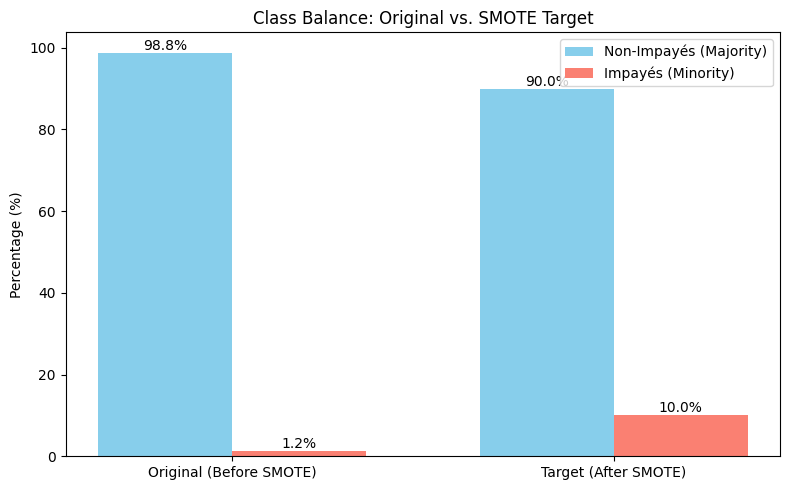


=== Candidate Models Metrics ===

--- Model: logreg_balanced ---


,Metric,Value
0,accuracy,0.817147
1,balanced_accuracy,0.519291
2,precision,0.015065
3,recall,0.213873
4,f1,0.028148
5,predicted_positive_rate,0.175768
6,roc_auc,0.512858
7,avg_precision,0.012897
8,threshold_opt_f1,0.581945
9,raw_roc_auc_before_inversion,0.487142



--- Model: hgb_balanced ---


,Metric,Value
0,accuracy,0.864668
1,balanced_accuracy,0.540496
2,precision,0.020112
3,recall,0.208092
4,f1,0.036679
5,predicted_positive_rate,0.128104
6,roc_auc,0.542042
7,avg_precision,0.015519
8,threshold_opt_f1,0.114102
9,raw_roc_auc_before_inversion,0.542042



--- Model: xgb_balanced ---


,Metric,Value
0,accuracy,0.589494
1,balanced_accuracy,0.541027
2,precision,0.014826
3,recall,0.491329
4,f1,0.028784
5,predicted_positive_rate,0.410291
6,roc_auc,0.523099
7,avg_precision,0.013607
8,threshold_opt_f1,0.041077
9,raw_roc_auc_before_inversion,0.523099



--- Model: rf_balanced ---


,Metric,Value
0,accuracy,0.403492
1,balanced_accuracy,0.518209
2,precision,0.013123
3,recall,0.635838
4,f1,0.025716
5,predicted_positive_rate,0.599871
6,roc_auc,0.503209
7,avg_precision,0.012233
8,threshold_opt_f1,0.750973
9,raw_roc_auc_before_inversion,0.496791



✅ Winning Model Selected: hgb_balanced


In [329]:
# Calling the API and displaying metrics interactively within the notebook
import requests
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

print("Triggering model training via API (this might take a few minutes)...")
try:
    response = requests.post("http://localhost:8000/api/v1/ml/train", json={}, timeout=300)
    response.raise_for_status()
    res = response.json()
    
    # 1. Class Balance Information
    orig_pos = res.get('positive_rate', 0)
    orig_neg = 1 - orig_pos
    smote_pos = 0.10
    smote_neg = 0.90
    
    balance_data = {
        "Total Rows": res.get("training_rows"),
        "Original Positive Rate": f"{orig_pos:.2%}",
        "SMOTE Target (Impayés)": f"{smote_pos:.2%}",
        "SMOTE Target (Non-Impayés)": f"{smote_neg:.2%}"
    }
    print("\n=== Class Balance Information ===")
    display(pd.DataFrame([balance_data]))
    
    # --- Plotting the Histogram (Bar Chart) ---
    fig, ax = plt.subplots(figsize=(8, 5))
    categories = ['Original (Before SMOTE)', 'Target (After SMOTE)']
    impayes = [orig_pos * 100, smote_pos * 100]
    non_impayes = [orig_neg * 100, smote_neg * 100]
    
    bar_width = 0.35
    x = range(len(categories))
    
    p1 = ax.bar([i - bar_width/2 for i in x], non_impayes, bar_width, label='Non-Impayés (Majority)', color='skyblue')
    p2 = ax.bar([i + bar_width/2 for i in x], impayes, bar_width, label='Impayés (Minority)', color='salmon')
    
    ax.set_ylabel('Percentage (%)')
    ax.set_title('Class Balance: Original vs. SMOTE Target')
    ax.set_xticks([i for i in x])
    ax.set_xticklabels(categories)
    ax.legend(loc='upper right')
    
    for container in [p1, p2]:
        ax.bar_label(container, fmt='%.1f%%')
        
    plt.tight_layout()
    plt.show()
    
    # 2. Display Candidate Models Metrics
    print("\n=== Candidate Models Metrics ===")
    candidates = res.get("candidate_results", {})
    
    for model_name, model_info in candidates.items():
        print(f"\n--- Model: {model_name} ---")
        if model_info and "metrics" in model_info:
            metrics_df = pd.DataFrame(list(model_info["metrics"].items()), columns=["Metric", "Value"])
            display(metrics_df)
        else:
            print("No metrics recorded.")
            
    print(f"\n✅ Winning Model Selected: {res.get('selected_model')}")

except requests.exceptions.RequestException as e:
    print(f"Error calling the training API: {e}")